# Generowanie znaków drogowych — DCGAN (Conditional)

Model: **Conditional DCGAN** z konwolucjami, Spectral Normalization i label embeddings.

- Wejście generatora: wektor szumu (128-dim) + embedding klasy
- Obrazki: 32×32, 3 kanały, normalizacja do [-1, 1]
- Wyjście: 1000 próbek zapisanych jako tensor `[1000, 3, 32, 32]`

## 1. Importy i konfiguracja

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from torch.nn.utils import spectral_norm

# Seed dla reprodukowalności
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Używane urządzenie: {DEVICE}')

Używane urządzenie: cpu


In [3]:
# =====================
# HYPERPARAMETRY
# =====================
DATA_DIR    = './trafic_32'   # <-- zmień na ścieżkę do datasetu
OUTPUT_NAME = 'poniedzialek_nazwisko1_nazwisko2'  # <-- zmień na swój prefix

IMAGE_SIZE  = 32
NC          = 3       # liczba kanałów
NZ          = 128     # rozmiar wektora szumu
NGF         = 64      # szerokość generatora
NDF         = 64      # szerokość dyskryminatora
BATCH_SIZE  = 64
NUM_EPOCHS  = 200
LR          = 2e-4
BETA1       = 0.5
BETA2       = 0.999
N_SAMPLES   = 1000    # liczba próbek do wygenerowania
SAVE_EVERY  = 20      # co ile epok zapisywać checkpoint

## 2. Wczytanie danych

In [4]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalizacja do [-1,1]
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
NUM_CLASSES = len(dataset.classes)
print(f'Liczba klas: {NUM_CLASSES}')
print(f'Liczba obrazków: {len(dataset)}')
print(f'Klasy: {dataset.classes[:10]}...')

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

Liczba klas: 43
Liczba obrazków: 39209
Klasy: ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009']...


/home/ziutek/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


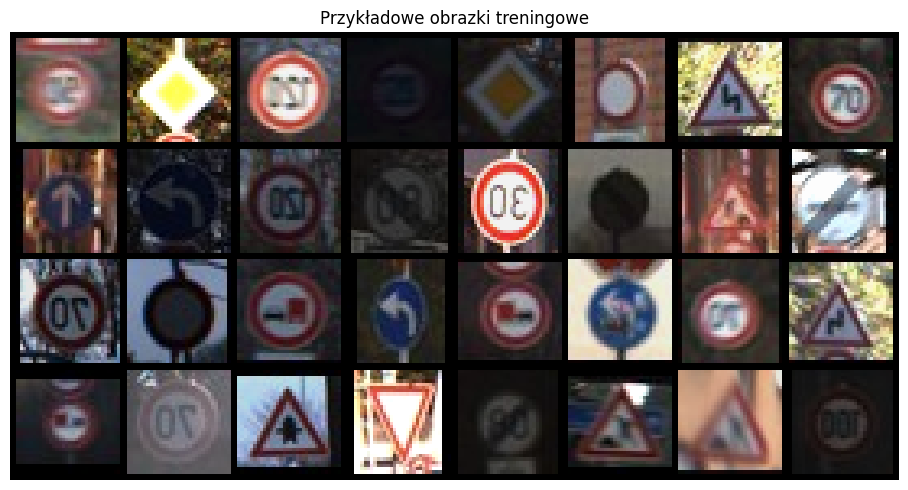

In [5]:
# Podgląd przykładowych obrazków z datasetu
real_batch = next(iter(dataloader))
imgs_to_show = real_batch[0][:32]

# Denormalizacja do [0,1] do wizualizacji
imgs_denorm = imgs_to_show * 0.5 + 0.5

grid = utils.make_grid(imgs_denorm, nrow=8, padding=2)
plt.figure(figsize=(12, 5))
plt.title('Przykładowe obrazki treningowe')
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Architektura modelu (Conditional DCGAN)

In [6]:
def weights_init(m):
    """Inicjalizacja wag jak w oryginalnym DCGAN."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    """
    Conditional Generator:
    Wejście: szum (NZ) + embedding klasy → obraz 3×32×32
    """
    def __init__(self, nz, ngf, nc, num_classes):
        super(Generator, self).__init__()

        # Embedding etykiety klasy → wektor o rozmiarze nz
        self.label_emb = nn.Embedding(num_classes, nz)

        # Wejście: (nz * 2) → 4×4
        self.net = nn.Sequential(
            # Blok 1: (nz*2) → ngf*8 @ 4×4
            nn.ConvTranspose2d(nz * 2, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # Blok 2: ngf*8 → ngf*4 @ 8×8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # Blok 3: ngf*4 → ngf*2 @ 16×16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # Blok 4: ngf*2 → nc @ 32×32
            nn.ConvTranspose2d(ngf * 2, nc, 4, 2, 1, bias=False),
            nn.Tanh()  # wyjście w zakresie [-1, 1]
        )

    def forward(self, z, labels):
        # Embedding etykiety + konkatenacja z szumem
        label_vec = self.label_emb(labels)           # [B, nz]
        inp = torch.cat([z, label_vec], dim=1)        # [B, nz*2]
        inp = inp.unsqueeze(-1).unsqueeze(-1)         # [B, nz*2, 1, 1]
        return self.net(inp)


class Discriminator(nn.Module):
    """
    Conditional Discriminator ze Spectral Normalization:
    Wejście: obraz 3×32×32 + embedding klasy jako dodatkowy kanał
    """
    def __init__(self, ndf, nc, num_classes, img_size):
        super(Discriminator, self).__init__()

        # Embedding etykiety → dodatkowy kanał obrazu (img_size × img_size)
        self.label_emb = nn.Embedding(num_classes, img_size * img_size)
        self.img_size  = img_size

        # Wejście: (nc + 1) kanałów (obraz + kanał etykiety)
        self.net = nn.Sequential(
            # Blok 1: (nc+1) → ndf @ 16×16
            spectral_norm(nn.Conv2d(nc + 1, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            # Blok 2: ndf → ndf*2 @ 8×8
            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Blok 3: ndf*2 → ndf*4 @ 4×4
            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Blok 4: ndf*4 → 1 @ 1×1
            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Etykieta jako dodatkowy kanał
        label_map = self.label_emb(labels)                          # [B, img_size*img_size]
        label_map = label_map.view(-1, 1, self.img_size, self.img_size)  # [B, 1, H, W]
        inp = torch.cat([img, label_map], dim=1)                   # [B, nc+1, H, W]
        return self.net(inp).view(-1)

In [7]:
# Inicjalizacja modeli
netG = Generator(NZ, NGF, NC, NUM_CLASSES).to(DEVICE)
netD = Discriminator(NDF, NC, NUM_CLASSES, IMAGE_SIZE).to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

print(f'Generator — liczba parametrów: {sum(p.numel() for p in netG.parameters()):,}')
print(f'Discriminator — liczba parametrów: {sum(p.numel() for p in netD.parameters()):,}')
print(netG)
print(netD)

Generator — liczba parametrów: 4,732,032
Discriminator — liczba parametrów: 708,352
Generator(
  (label_emb): Embedding(43, 128)
  (net): Sequential(
    (0): ConvTranspose2d(256, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (label_emb): Embedding(43, 1024)
  (net): Sequential(
    (0): Conv2d(4, 64, kerne

## 4. Trening

In [8]:
# Funkcja straty i optymalizatory
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, BETA2))

# Ustalony szum do wizualizacji postępu
fixed_noise  = torch.randn(64, NZ, device=DEVICE)
fixed_labels = torch.randint(0, NUM_CLASSES, (64,), device=DEVICE)

# Label smoothing — stabilizuje trening
REAL_LABEL = 0.9
FAKE_LABEL = 0.0

G_losses, D_losses = [], []
os.makedirs('checkpoints', exist_ok=True)

Rozpoczynam trening...
[Epoka   1/200]  Loss_D: 0.6577  Loss_G: 2.4273


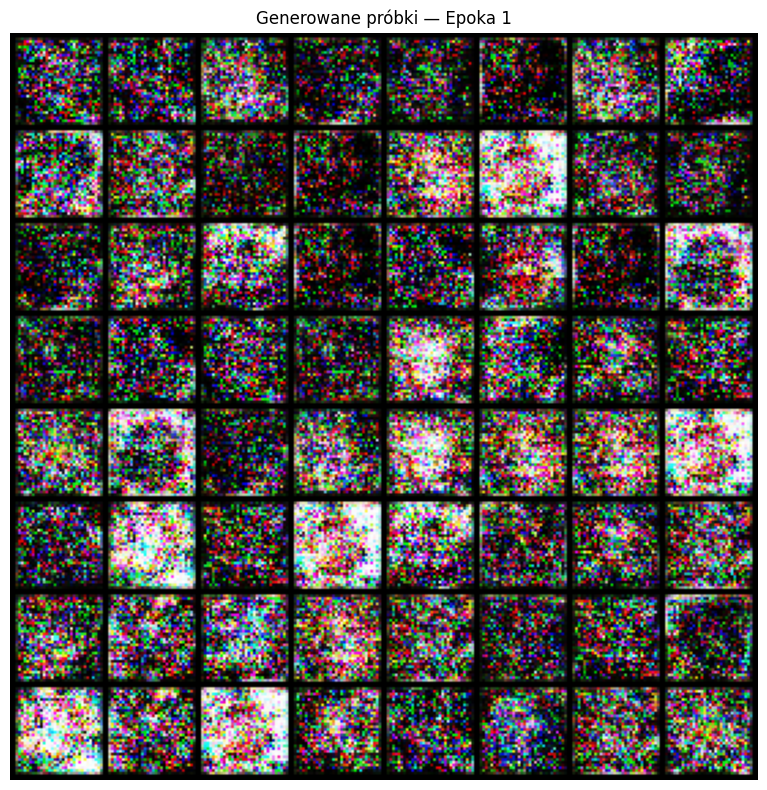

In [ ]:
print('Rozpoczynam trening...')

for epoch in range(NUM_EPOCHS):
    netG.train()
    netD.train()

    epoch_lossG = 0.0
    epoch_lossD = 0.0

    for i, (real_imgs, real_labels) in enumerate(dataloader):
        real_imgs   = real_imgs.to(DEVICE)
        real_labels = real_labels.to(DEVICE)
        b_size = real_imgs.size(0)

        # ──────────────────────────────
        # 1) Aktualizacja Dyskryminatora
        # ──────────────────────────────
        netD.zero_grad()

        # Prawdziwe obrazki
        label_real = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=DEVICE)
        # Drobny szum na etykiety prawdziwych (extra stabilizacja)
        label_real += 0.05 * torch.rand_like(label_real)

        output_real = netD(real_imgs, real_labels)
        errD_real   = criterion(output_real, label_real)
        errD_real.backward()

        # Fałszywe obrazki
        noise        = torch.randn(b_size, NZ, device=DEVICE)
        fake_labels  = torch.randint(0, NUM_CLASSES, (b_size,), device=DEVICE)
        fake_imgs    = netG(noise, fake_labels)

        label_fake   = torch.full((b_size,), FAKE_LABEL, dtype=torch.float, device=DEVICE)
        output_fake  = netD(fake_imgs.detach(), fake_labels)
        errD_fake    = criterion(output_fake, label_fake)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        # ──────────────────────────────
        # 2) Aktualizacja Generatora
        # ──────────────────────────────
        netG.zero_grad()

        # Generator chce, żeby dyskryminator widział fałszywe jako prawdziwe
        label_for_G = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=DEVICE)
        output_G    = netD(fake_imgs, fake_labels)
        errG        = criterion(output_G, label_for_G)
        errG.backward()
        optimizerG.step()

        epoch_lossD += errD.item()
        epoch_lossG += errG.item()

    # ──────────────────────────────
    # Logowanie i wizualizacja
    # ──────────────────────────────
    avg_lossD = epoch_lossD / len(dataloader)
    avg_lossG = epoch_lossG / len(dataloader)
    G_losses.append(avg_lossG)
    D_losses.append(avg_lossD)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'[Epoka {epoch+1:3d}/{NUM_EPOCHS}]  '
              f'Loss_D: {avg_lossD:.4f}  Loss_G: {avg_lossG:.4f}')

    # Checkpoint + wizualizacja generatora
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        torch.save({
            'epoch': epoch + 1,
            'netG_state_dict': netG.state_dict(),
            'netD_state_dict': netD.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerD_state_dict': optimizerD.state_dict(),
        }, f'checkpoints/checkpoint_epoch_{epoch+1:03d}.pt')

        # Wizualizacja przykładowych próbek
        netG.eval()
        with torch.no_grad():
            fake_sample = netG(fixed_noise, fixed_labels)
        fake_sample_denorm = fake_sample * 0.5 + 0.5

        grid = utils.make_grid(fake_sample_denorm.cpu(), nrow=8, padding=2)
        plt.figure(figsize=(12, 8))
        plt.title(f'Generowane próbki — Epoka {epoch+1}')
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        netG.train()

print('Trening zakończony!')

## 5. Krzywe strat

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(G_losses, label='Generator', alpha=0.8)
plt.plot(D_losses, label='Discriminator', alpha=0.8)
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Krzywe strat GAN podczas treningu')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Generowanie 1000 próbek i zapis

In [ ]:
def generate_samples(model, num_samples, num_classes, nz, device, batch_size=100):
    """
    Generuje `num_samples` próbek z równomiernym rozkładem klas.
    Zwraca zdenormalizowany tensor [N, 3, 32, 32] z wartościami w [0, 1].
    """
    model.eval()
    all_imgs = []

    # Równomierny rozkład klas
    samples_per_class = num_samples // num_classes
    remainder         = num_samples % num_classes
    class_counts      = [samples_per_class] * num_classes
    for i in range(remainder):
        class_counts[i] += 1

    with torch.no_grad():
        for cls_idx, count in enumerate(class_counts):
            # Generuj w batch'ach
            generated = 0
            while generated < count:
                bs    = min(batch_size, count - generated)
                noise = torch.randn(bs, nz, device=device)
                lbls  = torch.full((bs,), cls_idx, dtype=torch.long, device=device)
                imgs  = model(noise, lbls)  # [-1, 1]
                # Denormalizacja do [0, 1]
                imgs  = imgs * 0.5 + 0.5
                imgs  = imgs.clamp(0, 1)
                all_imgs.append(imgs.cpu())
                generated += bs

    all_imgs = torch.cat(all_imgs, dim=0)  # [N, 3, 32, 32]
    # Przetasowanie kolejności próbek
    perm = torch.randperm(all_imgs.size(0))
    return all_imgs[perm]


generated_imgs = generate_samples(
    netG, N_SAMPLES, NUM_CLASSES, NZ, DEVICE
)
print(f'Kształt tensora: {generated_imgs.shape}')   # powinno być [1000, 3, 32, 32]
print(f'Min: {generated_imgs.min():.4f}, Max: {generated_imgs.max():.4f}')

In [ ]:
# Podgląd wygenerowanych próbek
sample_grid = utils.make_grid(generated_imgs[:64], nrow=8, padding=2)
plt.figure(figsize=(12, 8))
plt.title('Wygenerowane próbki (pierwsze 64)')
plt.imshow(sample_grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Zapis tensora zgodnie z wymogami zadania
# Tensor: [1000, 3, 32, 32], na CPU, po detach, wartości w [0, 1]
save_path = f'{OUTPUT_NAME}.pt'
torch.save(generated_imgs.cpu().detach(), save_path)
print(f'Zapisano próbki do: {save_path}')
print(f'Kształt: {generated_imgs.shape}')
print(f'Dtype: {generated_imgs.dtype}')

# Weryfikacja
loaded = torch.load(save_path)
print(f'Weryfikacja — kształt załadowanego tensora: {loaded.shape}')
assert loaded.shape == (1000, 3, 32, 32), 'BŁĄD: nieprawidłowy kształt tensora!'
print('OK — tensor ma poprawny kształt [1000, 3, 32, 32]')

## 7. (Opcjonalnie) Ewaluacja FID

Wymaga zainstalowania: `pip install pytorch-fid`

```bash
# Najpierw zapisz wygenerowane obrazki jako pliki PNG:
# python save_imgs_for_fid.py
# Następnie:
# python -m pytorch_fid path/to/real_imgs path/to/generated_imgs
```

In [ ]:
# Pomocniczy skrypt do zapisu PNG dla FID (opcjonalnie)
import os
from torchvision.utils import save_image

FID_DIR = 'fid_generated'
os.makedirs(FID_DIR, exist_ok=True)

for idx, img in enumerate(generated_imgs):
    save_image(img, os.path.join(FID_DIR, f'{idx:04d}.png'))

print(f'Zapisano {len(generated_imgs)} obrazków do folderu: {FID_DIR}/')
print('Aby policzyć FID, uruchom:')
print(f'  python -m pytorch_fid path/do/prawdziwych {FID_DIR}/')

## 8. (Opcjonalnie) Wczytanie checkpointu

Jeśli chcesz wznowić trening lub załadować najlepszy checkpoint:

In [ ]:
# Wczytanie konkretnego checkpointu (odkomentuj i zmień ścieżkę)
# checkpoint = torch.load('checkpoints/checkpoint_epoch_200.pt', map_location=DEVICE)
# netG.load_state_dict(checkpoint['netG_state_dict'])
# netD.load_state_dict(checkpoint['netD_state_dict'])
# optimizerG.load_state_dict(checkpoint['optimizerG_state_dict'])
# optimizerD.load_state_dict(checkpoint['optimizerD_state_dict'])
# print(f"Wczytano checkpoint z epoki: {checkpoint['epoch']}")